--- FINANCIAL SUMMARY (YEAR 1) ---
Estimated Labor Savings:  ₹25,000,000.00
Estimated Error Savings:  ₹10,000,000.00
Total Annual Savings:     ₹35,000,000.00
Net Benefit (Year 1):     ₹5,000,000.00
ROI:                      116.67%


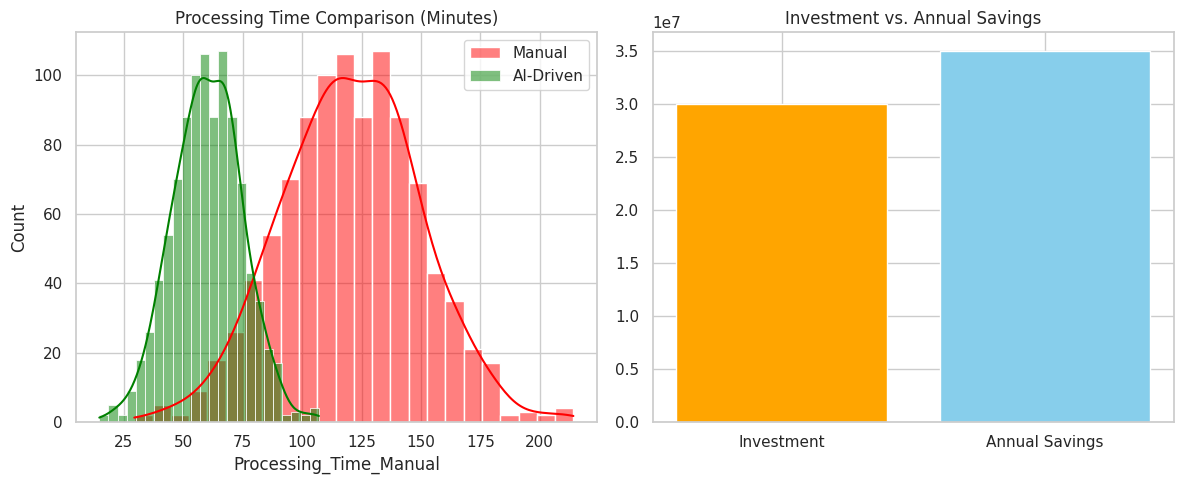

/tmp/ipykernel_643/180208674.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f"{int(s*100)}% Speedup" for s in scenarios], y=benefits, ax=axes[1, 0], palette="viridis")


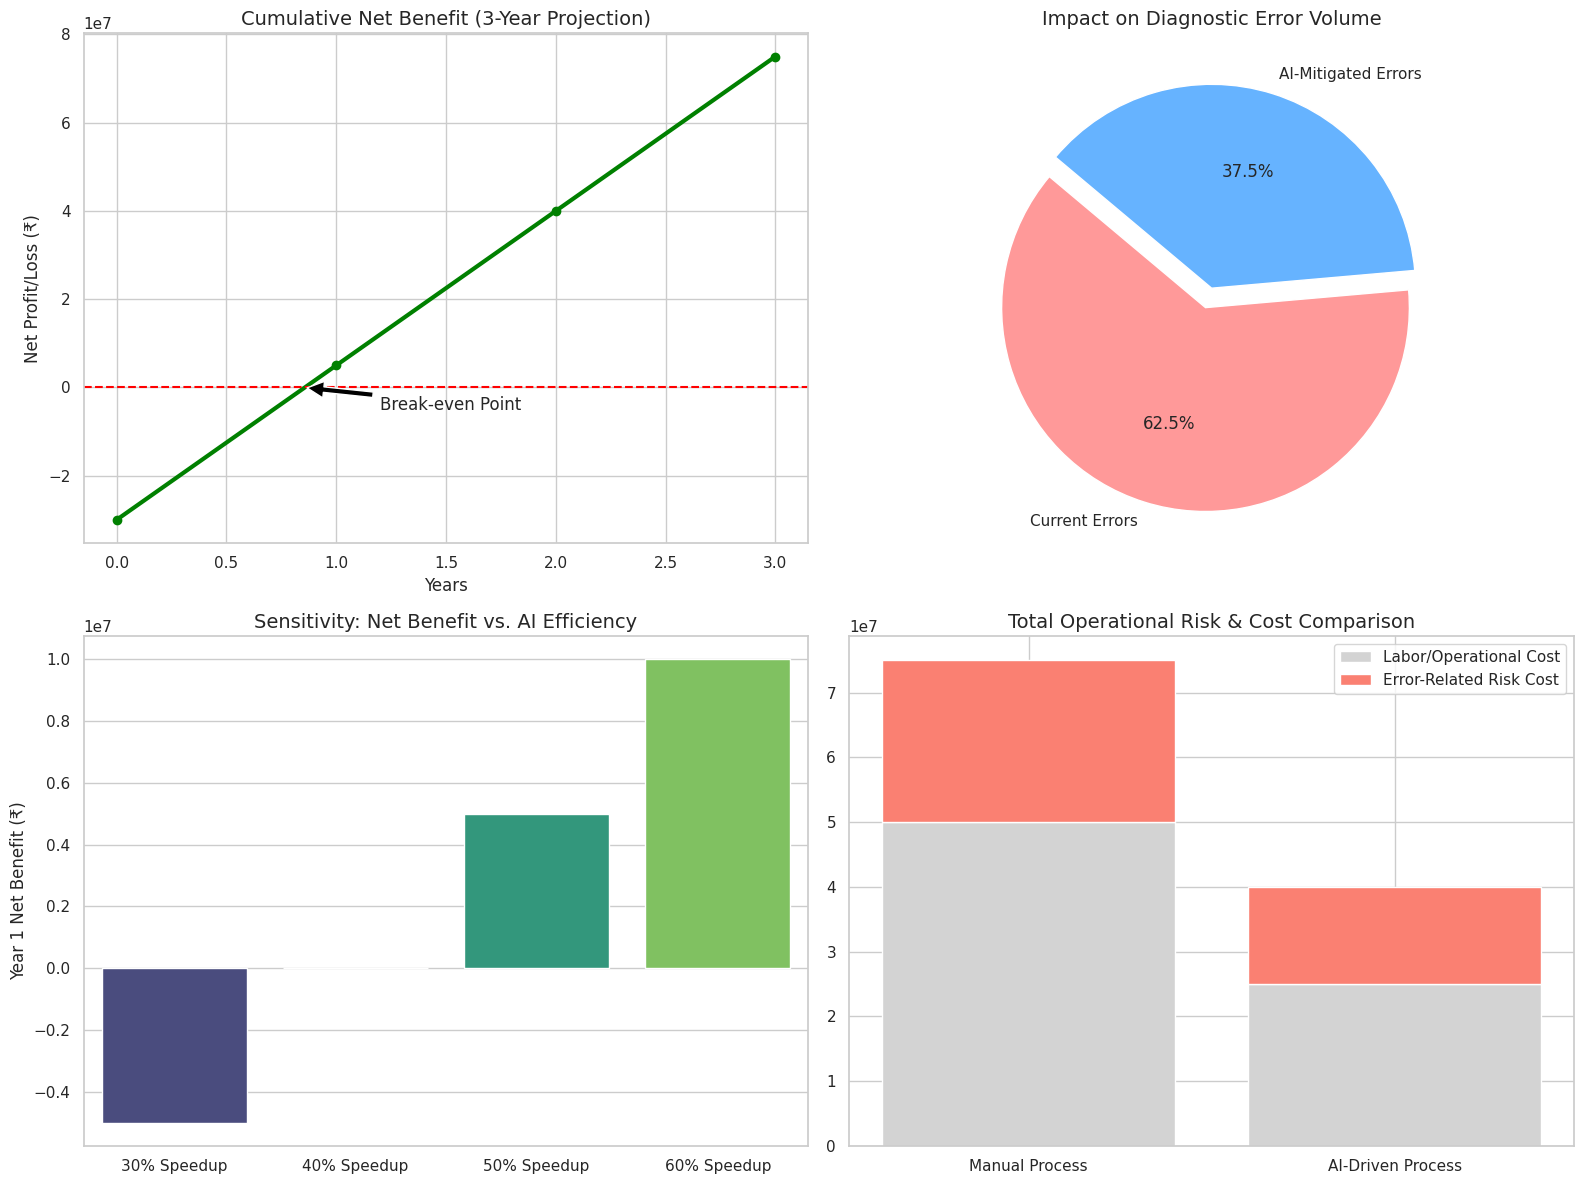

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION & CONSTANTS ---
INVESTMENT = 30000000  # ₹3 Crores
ANNUAL_REPORTS = 100000 # Number of tests/reports per year
CURRENT_AVG_COST_PER_REPORT = 500 # Labor, overhead, etc.
ERROR_RATE = 0.05 # 5% current error rate
AVG_COST_PER_ERROR = 5000 # Legal, re-tests, reputation loss

# AI Improvements
TIME_REDUCTION = 0.50  #50% faster
ERROR_REDUCTION = 0.40 #40% fewer errors

# --- 2. GENERATING SYNTHETIC PATIENT DATA (Technical Analysis) ---
def generate_synthetic_data(n=1000):
    np.random.seed(42)
    data = {
        'Patient_ID': range(1001, 1001 + n),
        'Hemoglobin': np.random.normal(13.5, 1.5, n), # Normal distribution
        'Glucose_Level': np.random.uniform(70, 200, n), # Random range
        'Processing_Time_Manual': np.random.normal(120, 30, n), # Minutes
        'Diagnostic_Accuracy': np.random.choice([0, 1], size=n, p=[ERROR_RATE, 1 - ERROR_RATE])
    }
    df = pd.DataFrame(data)

    # Simulate AI Performance
    df['Processing_Time_AI'] = df['Processing_Time_Manual'] * (1 - TIME_REDUCTION)
    return df

df_sim = generate_synthetic_data(ANNUAL_REPORTS // 100) # Small sample for display

# --- 3. FINANCIAL ANALYSIS CALCULATIONS ---
# Annual Labor/Processing Savings
current_total_processing_cost = ANNUAL_REPORTS * CURRENT_AVG_COST_PER_REPORT
savings_labor = current_total_processing_cost * TIME_REDUCTION

# Error Cost Savings
current_error_cost = ANNUAL_REPORTS * ERROR_RATE * AVG_COST_PER_ERROR
savings_errors = current_error_cost * ERROR_REDUCTION

total_annual_savings = savings_labor + savings_errors
net_benefit_year_1 = total_annual_savings - INVESTMENT

# --- 4. OUTPUTS & RESULTS ---
print(f"--- FINANCIAL SUMMARY (YEAR 1) ---")
print(f"Estimated Labor Savings:  ₹{savings_labor:,.2f}")
print(f"Estimated Error Savings:  ₹{savings_errors:,.2f}")
print(f"Total Annual Savings:     ₹{total_annual_savings:,.2f}")
print(f"Net Benefit (Year 1):     ₹{net_benefit_year_1:,.2f}")
print(f"ROI:                      {(total_annual_savings/INVESTMENT)*100:.2f}%")

# --- 5. VISUALIZATION ---
plt.figure(figsize=(12, 5))

# Plot 1: Processing Time Improvement
plt.subplot(1, 2, 1)
sns.histplot(df_sim['Processing_Time_Manual'], color='red', label='Manual', kde=True)
sns.histplot(df_sim['Processing_Time_AI'], color='green', label='AI-Driven', kde=True)
plt.title('Processing Time Comparison (Minutes)')
plt.legend()

# Plot 2: Financial Breakdown
plt.subplot(1, 2, 2)
labels = ['Investment', 'Annual Savings']
values = [INVESTMENT, total_annual_savings]
plt.bar(labels, values, color=['orange', 'skyblue'])
plt.title('Investment vs. Annual Savings')

plt.tight_layout()
plt.show()


# --- 6. ADDITIONAL ADVANCED VISUALIZATIONS ---

# Set style for professional look
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- CHART 1: Cumulative Cash Flow (Break-even Analysis) ---
years = np.arange(0, 4) # 3 Year projection
# Year 0 is just the investment (negative)
cumulative_cash_flow = [-INVESTMENT]
for y in range(1, 4):
    cumulative_cash_flow.append(cumulative_cash_flow[-1] + total_annual_savings)

axes[0, 0].plot(years, cumulative_cash_flow, marker='o', linewidth=3, color='green')
axes[0, 0].axhline(0, color='red', linestyle='--') # Break-even line
axes[0, 0].set_title('Cumulative Net Benefit (3-Year Projection)', fontsize=14)
axes[0, 0].set_xlabel('Years')
axes[0, 0].set_ylabel('Net Profit/Loss (₹)')
axes[0, 0].annotate('Break-even Point', xy=(0.85, 0), xytext=(1.2, -5000000),
             arrowprops=dict(facecolor='black', shrink=0.05))

# --- CHART 2: Error Reduction Comparison (Quality Improvement) ---
error_labels = ['Current Errors', 'AI-Mitigated Errors']
error_values = [ANNUAL_REPORTS * ERROR_RATE, (ANNUAL_REPORTS * ERROR_RATE) * (1 - ERROR_REDUCTION)]

axes[0, 1].pie(error_values, labels=error_labels, autopct='%1.1f%%',
               colors=['#ff9999','#66b3ff'], startangle=140, explode=(0.1, 0))
axes[0, 1].set_title('Impact on Diagnostic Error Volume', fontsize=14)

# --- CHART 3: Sensitivity Analysis (What if savings vary?) ---
# We check how Net Benefit changes if time reduction is 30%, 40%, 50%, or 60%
scenarios = [0.3, 0.4, 0.5, 0.6]
benefits = [(current_total_processing_cost * s + savings_errors) - INVESTMENT for s in scenarios]

sns.barplot(x=[f"{int(s*100)}% Speedup" for s in scenarios], y=benefits, ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title('Sensitivity: Net Benefit vs. AI Efficiency', fontsize=14)
axes[1, 0].set_ylabel('Year 1 Net Benefit (₹)')

# --- CHART 4: Cost Breakdown Stacked Bar ---
categories = ['Manual Process', 'AI-Driven Process']
labor_costs = [current_total_processing_cost, current_total_processing_cost * (1-TIME_REDUCTION)]
error_costs = [current_error_cost, current_error_cost * (1-ERROR_REDUCTION)]

axes[1, 1].bar(categories, labor_costs, label='Labor/Operational Cost', color='lightgrey')
axes[1, 1].bar(categories, error_costs, bottom=labor_costs, label='Error-Related Risk Cost', color='salmon')
axes[1, 1].set_title('Total Operational Risk & Cost Comparison', fontsize=14)
axes[1, 1].legend()

plt.tight_layout()
plt.show()